# Exploratory Data Analysis — Traffic Volume Dataset (Raw)

**Scope:** This notebook performs an Exploratory Data Analysis (EDA) on the **raw, untouched** `traffic_volume.csv` dataset.

> ⚠️ **No modifications are made to the dataset in this notebook.** No rows or columns are added or removed, and no values are cleaned, imputed, transformed, encoded, or scaled. All operations below are strictly read-only / analytical. The goal is to understand the data as it currently exists and to catalogue issues that a later, separate **Cleaning** notebook/stage should address.

**Dataset:** `traffic_volume.csv`


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting configuration (cosmetic only — does not affect the data)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RAW_PATH = "traffic_volume.csv"


## 1. Dataset Overview

Load the raw CSV **exactly as provided** and inspect its basic structure: shape, column names, data types, and general info.


In [2]:
# Load the raw dataset. No parsing/cleaning arguments are applied beyond a plain read_csv,
# so the data is loaded exactly as it exists in the source file.
df = pd.read_csv(RAW_PATH)

print(f"Shape (rows, columns): {df.shape}")


Shape (rows, columns): (48204, 9)


In [3]:
df.columns.tolist()


['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

In [4]:
df.dtypes.to_frame(name="dtype")


,dtype
holiday,str
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,str
weather_description,str
date_time,str
traffic_volume,int64


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [6]:
df.head(10)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
5,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181
6,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,5584
7,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,6015
8,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,5791
9,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,4770


In [7]:
df.tail(5)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


**Observations so far:**
- The dataset contains **48,204 rows** and **9 columns**.
- Columns mix numeric types (`temp`, `rain_1h`, `snow_1h`, `clouds_all`, `traffic_volume`) with object/text types (`holiday`, `weather_main`, `weather_description`, `date_time`).
- `date_time` is currently stored as a **string**, not as a proper datetime type — this is noted for the Cleaning stage but is **not** converted here, since type conversion counts as a transformation.


## 2. Missing Values Analysis

Check for missing values across all columns, both as raw counts and as a percentage of the total dataset.


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary


,missing_count,missing_pct
holiday,48143,99.87
temp,0,0.00
rain_1h,0,0.00
snow_1h,0,0.00
clouds_all,0,0.00
weather_main,0,0.00
weather_description,0,0.00
date_time,0,0.00
traffic_volume,0,0.00


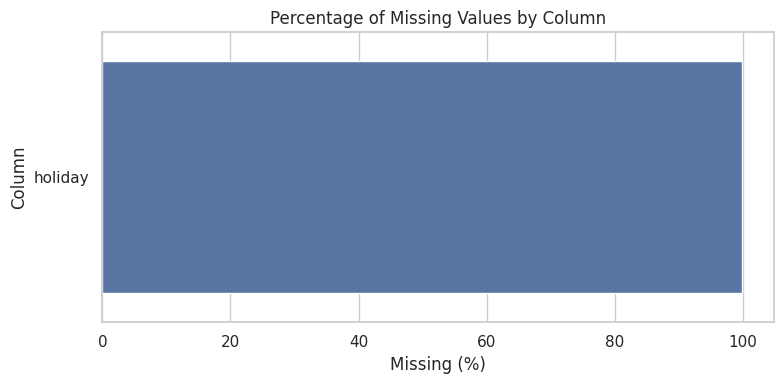

In [9]:
plt.figure(figsize=(8, 4))
missing_summary_nonzero = missing_summary[missing_summary["missing_count"] > 0]
sns.barplot(
    x=missing_summary_nonzero["missing_pct"],
    y=missing_summary_nonzero.index,
    color="#4C72B0"
)
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.title("Percentage of Missing Values by Column")
plt.tight_layout()
plt.show()


**Findings:**
- `holiday` is missing in the vast majority of rows (~99.9%). This is very likely **not a data quality defect** — it probably means "not a holiday" for that hourly record, rather than a truly unknown value. This distinction/interpretation should be handled explicitly at the Cleaning stage.
- All other columns (`temp`, `rain_1h`, `snow_1h`, `clouds_all`, `weather_main`, `weather_description`, `date_time`, `traffic_volume`) have **0 missing values**.


## 3. Duplicate Rows Analysis

Check for fully duplicated rows, as well as duplicated timestamps (which is a strong signal for time-series data even if the full row is not identical).


In [10]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows (all columns identical): {full_dupes}")


Fully duplicated rows (all columns identical): 17


In [11]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
29267,NaN,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
29268,NaN,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
39526,NaN,266.220,0.0,0.0,1,Clear,sky is clear,2017-12-05 18:00:00,3936
39527,NaN,266.220,0.0,0.0,1,Clear,sky is clear,2017-12-05 18:00:00,3936
28878,NaN,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
28879,NaN,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
38674,NaN,278.720,0.0,0.0,90,Drizzle,light intensity drizzle,2017-11-05 01:00:00,629
38676,NaN,278.720,0.0,0.0,90,Drizzle,light intensity drizzle,2017-11-05 01:00:00,629
38675,NaN,278.720,0.0,0.0,90,Mist,mist,2017-11-05 01:00:00,629
38677,NaN,278.720,0.0,0.0,90,Mist,mist,2017-11-05 01:00:00,629


In [12]:
dt_dupes = df["date_time"].duplicated().sum()
print(f"Rows sharing a date_time value with another row: {dt_dupes}")
print(f"Unique date_time values: {df['date_time'].nunique()} out of {len(df)} rows")


Rows sharing a date_time value with another row: 7629
Unique date_time values: 40575 out of 48204 rows


In [13]:
df[df["date_time"].duplicated(keep=False)].sort_values("date_time").head(10)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685
271,NaN,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685
272,NaN,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370


**Findings:**
- There are **17 fully duplicated rows** (every column identical) — candidates for removal at the Cleaning stage.
- There are **7,629 rows that share a `date_time` value** with at least one other row. Since this is hourly traffic data, a timestamp is expected to be unique. This is the single most significant data quality issue found in this dataset and will need a clear resolution strategy (e.g., de-duplication rule, aggregation, or root-cause investigation) during Cleaning.


## 4. Unique Values and Categorical Distributions

Inspect the cardinality and value distributions of the categorical/text columns: `holiday`, `weather_main`, `weather_description`.


In [14]:
categorical_cols = ["holiday", "weather_main", "weather_description"]

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"  Unique values: {df[col].nunique(dropna=True)}")
    print(f"  Sample values: {sorted(df[col].dropna().unique())[:10]}")
    print()


Column: holiday
  Unique values: 11
  Sample values: ['Christmas Day', 'Columbus Day', 'Independence Day', 'Labor Day', 'Martin Luther King Jr Day', 'Memorial Day', 'New Years Day', 'State Fair', 'Thanksgiving Day', 'Veterans Day']

Column: weather_main
  Unique values: 11
  Sample values: ['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall']

Column: weather_description
  Unique values: 38
  Sample values: ['SQUALLS', 'Sky is Clear', 'broken clouds', 'drizzle', 'few clouds', 'fog', 'freezing rain', 'haze', 'heavy intensity drizzle', 'heavy intensity rain']



In [15]:
df["weather_main"].value_counts()


weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

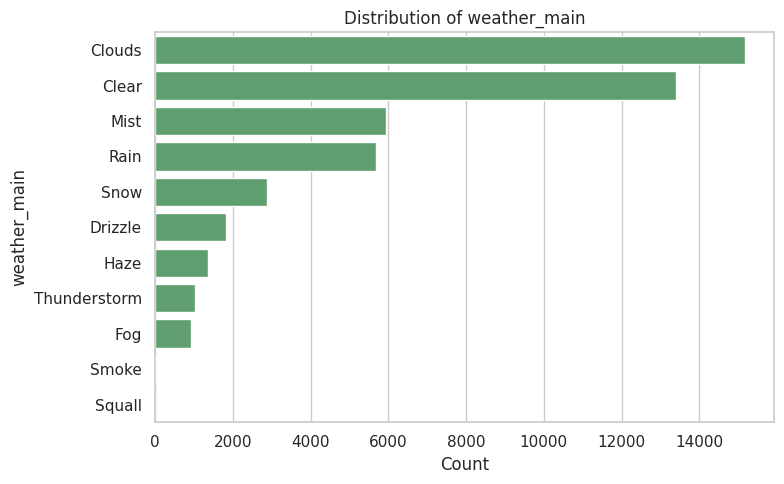

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df["weather_main"].value_counts().index
sns.countplot(data=df, y="weather_main", order=order, color="#55A868", ax=ax)
ax.set_title("Distribution of weather_main")
ax.set_xlabel("Count")
ax.set_ylabel("weather_main")
plt.tight_layout()
plt.show()


In [17]:
df["weather_description"].value_counts()


weather_description
sky is clear                           11665
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                              3372
few clouds                              1956
light snow                              1946
Sky is Clear                            1726
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1100
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             125
heavy intensity drizzle                   64
thunderstorm with heavy rain       

In [18]:
df["holiday"].value_counts()


holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

**Findings:**
- `weather_main` has **11 categories**, dominated by `Clouds` and `Clear`.
- `weather_description` has **38 distinct text values**, several of which appear to be **inconsistent casing of the same underlying category** — e.g. `"sky is clear"` (11,665 rows) vs. `"Sky is Clear"` (1,726 rows), and `"SQUALLS"` appears in uppercase while the rest of the column is lowercase. This is a categorical consistency issue for Cleaning, not addressed here.
- `holiday` only ever takes on named US holidays (e.g. `Labor Day`, `Christmas Day`, `Thanksgiving Day`) when it is not missing, each occurring only 5–7 times across ~6 years of data, consistent with one entry per year per holiday.


## 5. Descriptive Statistics

Summary statistics for numerical and categorical columns.


In [19]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
temp,48204.0,281.205870,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,0.334264,44.789133,0.0,0.00,0.00,0.000,9831.30
snow_1h,48204.0,0.000222,0.008168,0.0,0.00,0.00,0.000,0.51
clouds_all,48204.0,49.362231,39.015750,0.0,1.00,64.00,90.000,100.00
traffic_volume,48204.0,3259.818355,1986.860670,0.0,1193.00,3380.00,4933.000,7280.00


In [20]:
df.describe(include="object").T


,count,unique,top,freq
holiday,61,11,Labor Day,7
weather_main,48204,11,Clouds,15164
weather_description,48204,38,sky is clear,11665
date_time,48204,40575,2013-04-18 22:00:00,6


**Findings:**
- `traffic_volume` ranges from **0 to 7,280**, with a mean around 3,260.
- `temp` (in Kelvin) ranges from **0 to 310.07**. A value of **0 K is physically implausible** (0 K = absolute zero) for a surface air temperature reading — this is almost certainly a sensor/data placeholder error, not a real recorded temperature.
- `rain_1h` has a maximum of **9,831.3**, several orders of magnitude above the next highest values (tens of mm), which is a strong outlier flag investigated further in Section 9.
- `snow_1h` ranges from 0 to 0.51, and is 0 for the overwhelming majority of rows.


## 6. Numerical Distributions — Histograms/KDE and Boxplots

Visualize the distribution shape and spread of each numerical column.


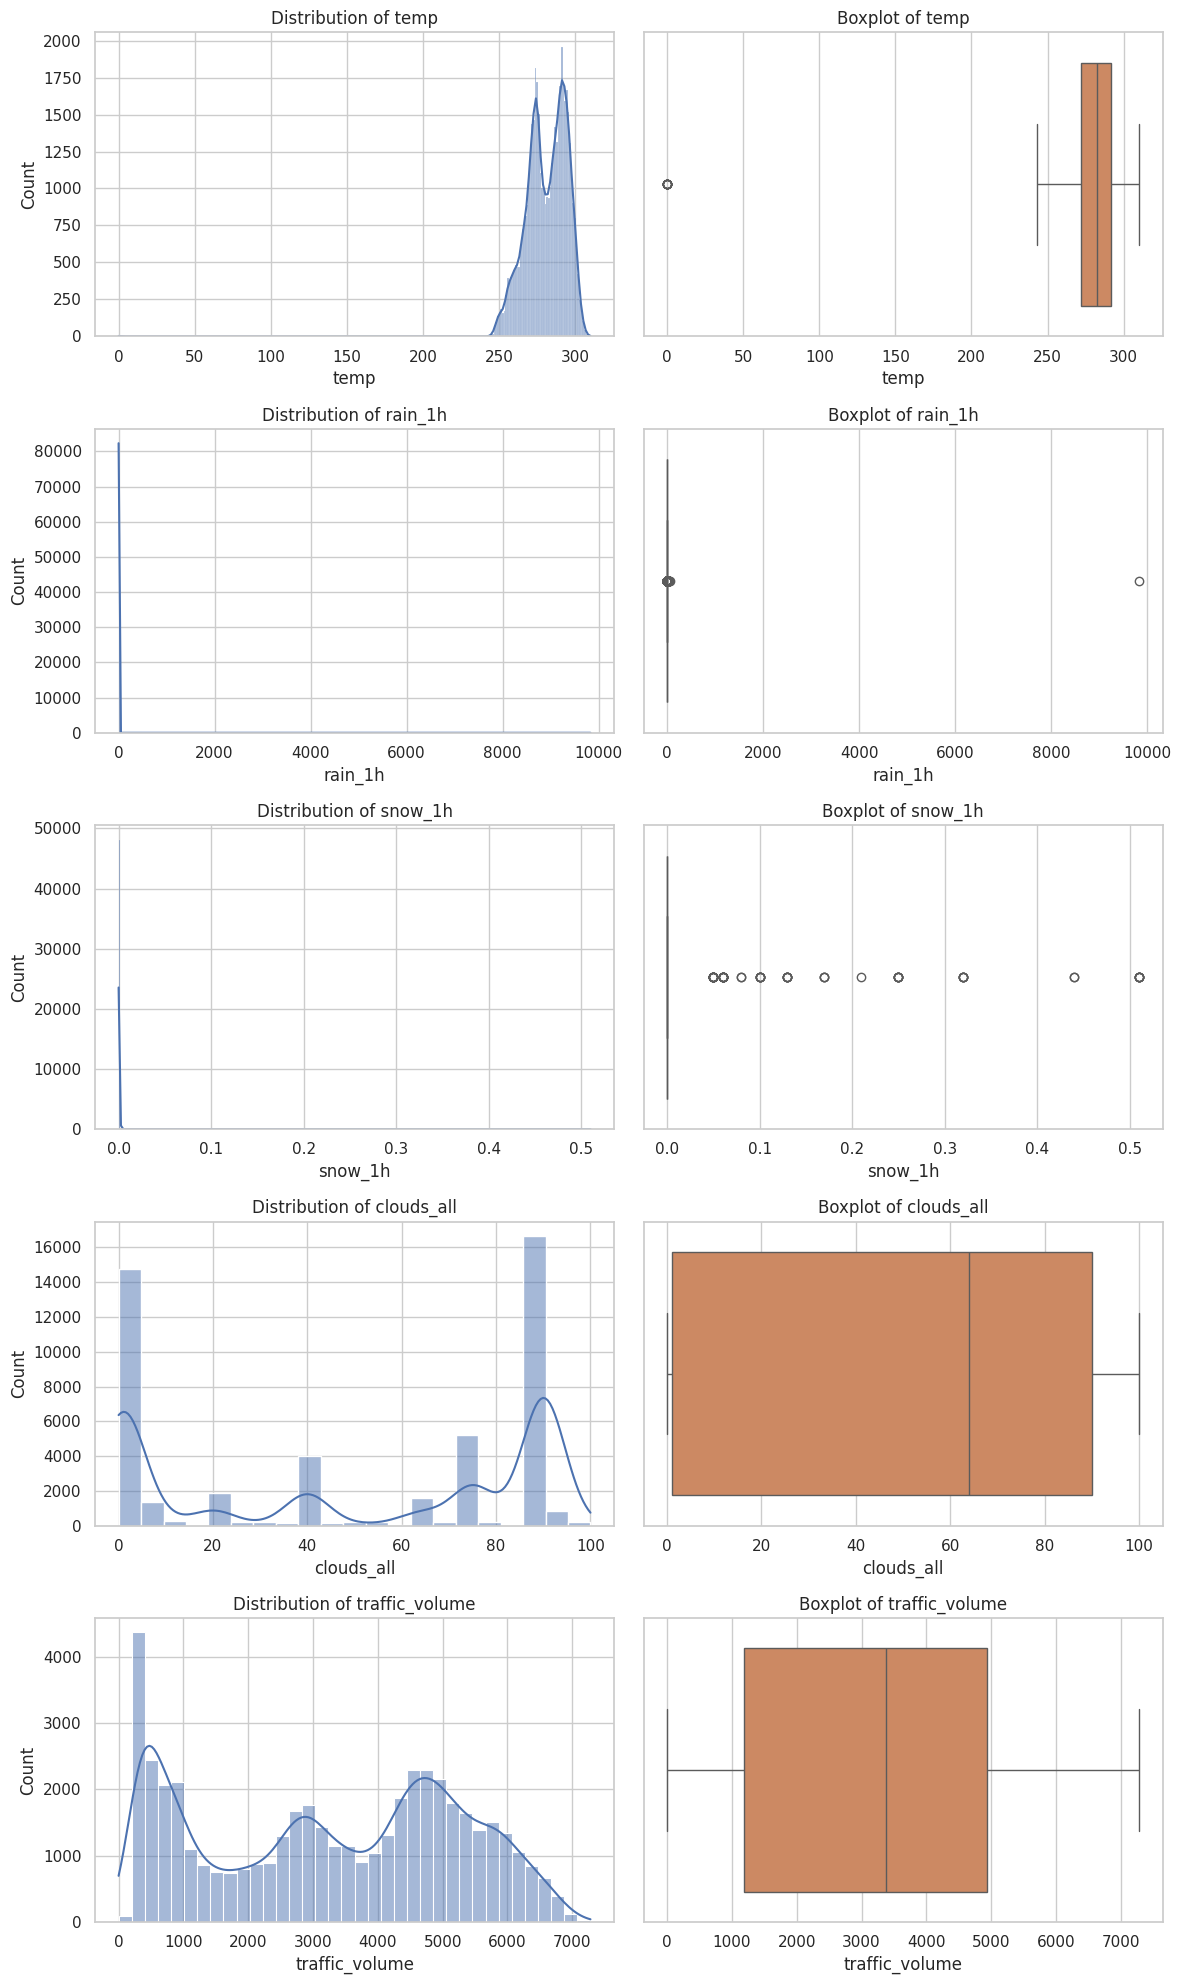

In [21]:
numerical_cols = ["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


**Findings:**
- `traffic_volume` and `clouds_all` show reasonably broad, multi-modal-looking spreads without extreme outliers.
- `temp` is roughly centered but shows a small cluster of exact-zero values pulling the lower tail into physically invalid territory.
- `rain_1h` and `snow_1h` are extremely right-skewed and dominated by zeros, with `rain_1h` showing one or more extreme spikes that compress the rest of the boxplot into an unreadable sliver — examined more closely in Section 9.


## 7. Skewness and Potential Outliers

Quantify skewness for each numerical column, and flag potential outliers using the IQR method (for reference only — no values are removed or altered).


In [22]:
skew_summary = df[numerical_cols].skew().sort_values(ascending=False).to_frame(name="skewness")
skew_summary


,skewness
rain_1h,219.389036
snow_1h,48.367484
traffic_volume,-0.089381
clouds_all,-0.197257
temp,-2.247226


In [23]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_rows = []
for col in numerical_cols:
    count, lower, upper = iqr_outlier_count(df[col])
    outlier_rows.append({
        "column": col,
        "iqr_lower_bound": round(lower, 3),
        "iqr_upper_bound": round(upper, 3),
        "outlier_count": count,
        "outlier_pct": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index("column")
outlier_summary


,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
column,,,,
temp,242.691,321.275,10,0.02
rain_1h,0.000,0.000,3467,7.19
snow_1h,0.000,0.000,63,0.13
clouds_all,-132.500,223.500,0,0.00
traffic_volume,-4417.000,10543.000,0,0.00


**Findings:**
- `rain_1h` and `snow_1h` show extremely high skewness, consistent with being near-zero-dominated with rare extreme values — typical for precipitation data, but the magnitude for `rain_1h` (max ~9,831) goes far beyond what a plausible hourly rainfall value (mm) should be.
- The IQR method flags a meaningful share of `rain_1h` and `snow_1h` values as outliers, which is expected given their distribution shape; not all of these are necessarily data errors, but the extreme maximum in `rain_1h` warrants explicit investigation below.
- `temp`, `clouds_all`, and `traffic_volume` show low-to-moderate skew, more consistent with genuine, well-behaved measurements.


## 8. Correlation Analysis

Examine linear relationships between the numerical columns.


In [24]:
corr_matrix = df[numerical_cols].corr(numeric_only=True)
corr_matrix


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
temp,1.000000,0.009069,-0.019755,-0.101976,0.130299
rain_1h,0.009069,1.000000,-0.000090,0.004818,0.004714
snow_1h,-0.019755,-0.000090,1.000000,0.027931,0.000733
clouds_all,-0.101976,0.004818,0.027931,1.000000,0.067054
traffic_volume,0.130299,0.004714,0.000733,0.067054,1.000000


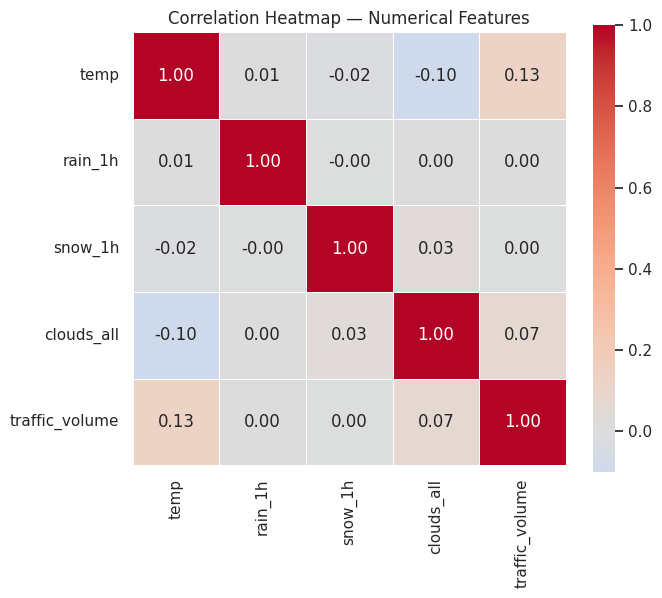

In [25]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


**Findings:**
- Correlations among the raw numerical features are generally **weak**. None of the weather-related variables (`temp`, `rain_1h`, `snow_1h`, `clouds_all`) show a strong linear relationship with `traffic_volume` in the raw data.
- This suggests that, if weather ends up being predictive of traffic volume, the relationship is likely non-linear or mediated by other factors (e.g., time of day, day of week extracted from `date_time`), which are not yet available as engineered features in this raw dataset — that engineering step belongs to a later feature-engineering stage, not this EDA.


## 9. Suspicious, Invalid, or Unusual Values

This section explicitly hunts for values that look invalid or inconsistent, without changing anything.


In [26]:
# 9.1 - Physically impossible temperature (0 Kelvin = absolute zero)
zero_temp = df[df["temp"] == 0]
print(f"Rows with temp == 0 (Kelvin): {len(zero_temp)}")
zero_temp


Rows with temp == 0 (Kelvin): 10


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670


In [27]:
# 9.2 - Extreme rain_1h value(s) far outside plausible hourly rainfall range
extreme_rain = df.sort_values("rain_1h", ascending=False).head(5)
extreme_rain[["date_time", "rain_1h", "weather_main", "weather_description", "traffic_volume"]]


,date_time,rain_1h,weather_main,weather_description,traffic_volume
24872,2016-07-11 17:00:00,9831.30,Rain,very heavy rain,5535
8247,2013-08-07 02:00:00,55.63,Rain,very heavy rain,315
7179,2013-06-24 11:00:00,44.45,Rain,very heavy rain,4802
25779,2016-08-16 17:00:00,31.75,Rain,very heavy rain,4913
10806,2013-12-19 23:00:00,28.70,Rain,very heavy rain,1190


In [28]:
# 9.3 - traffic_volume == 0 (a fully empty road for an entire hour is unusual and worth flagging)
zero_traffic = df[df["traffic_volume"] == 0]
print(f"Rows with traffic_volume == 0: {len(zero_traffic)}")
zero_traffic


Rows with traffic_volume == 0: 2


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
25186,NaN,296.68,0.0,0.0,40,Rain,light rain,2016-07-23 18:00:00,0
25191,NaN,295.90,0.0,0.0,90,Haze,haze,2016-07-23 23:00:00,0


In [29]:
# 9.4 - Inconsistent text casing within weather_description (same category, different case)
case_check = df["weather_description"].value_counts()
case_check[case_check.index.str.lower().duplicated(keep=False)]


weather_description
sky is clear    11665
Sky is Clear     1726
Name: count, dtype: int64

In [30]:
# 9.5 - date_time range and basic chronological sanity check
print(f"Earliest timestamp: {df['date_time'].min()}")
print(f"Latest timestamp:   {df['date_time'].max()}")
print(f"date_time dtype:    {df['date_time'].dtype}  (stored as text, not parsed as datetime here)")


Earliest timestamp: 2012-10-02 09:00:00
Latest timestamp:   2018-09-30 23:00:00
date_time dtype:    str  (stored as text, not parsed as datetime here)


**Findings:**
- **10 rows** have `temp == 0` (Kelvin), which is physically impossible for ambient air temperature and almost certainly a placeholder/sensor-error value rather than a genuine reading.
- The single largest `rain_1h` value (**9,831.3**) is dramatically higher than the next highest value (~55.6) and than any plausible hourly rainfall total — a strong candidate for a data entry/unit error.
- **2 rows** have `traffic_volume == 0`, which is possible (e.g., road closure) but unusual enough to flag for review rather than assume is valid.
- `weather_description` contains the same real-world condition recorded under different text casing (`"sky is clear"` vs `"Sky is Clear"`, and `"SQUALLS"` vs `"squalls"`-style casing elsewhere), which will artificially inflate category counts unless normalized.
- `date_time` spans **2012-10-02 through 2018-09-30** and is stored as plain text, not as a datetime type, in the raw file.


## Raw Data EDA Summary

The dataset (**48,204 rows × 9 columns**) was explored in its original, unmodified form. **No values, rows, or columns were changed, removed, added, imputed, or transformed in this notebook.** The following issues were identified and should be explicitly addressed during a later, separate **Cleaning** stage:

1. **Missing values in `holiday`** — ~99.9% missing. Likely represents "not a holiday" rather than a true unknown; needs an explicit handling decision (e.g., fill with a sentinel like `"None"` vs. treat as missing).
2. **Duplicate rows** — 17 fully duplicated rows (all columns identical) should be reviewed for removal.
3. **Duplicate timestamps** — 7,629 rows share a `date_time` value with another row, which is unexpected for hourly data and is the most significant structural issue found; needs a de-duplication or aggregation strategy.
4. **`date_time` stored as text** — not yet parsed into a proper datetime type; needed before any time-based feature engineering or time-series analysis.
5. **Invalid `temp` values** — 10 rows record `temp == 0` Kelvin, which is physically impossible and likely a placeholder/error value.
6. **Extreme outlier in `rain_1h`** — a single value of 9,831.3 is far outside any plausible hourly rainfall range and should be investigated as a probable data error.
7. **Highly skewed `rain_1h` / `snow_1h`** — dominated by zeros with rare extreme spikes; any modeling use will likely require special handling (e.g., transformation or binning) beyond simple outlier removal.
8. **Inconsistent categorical text casing in `weather_description`** — the same condition appears under different capitalizations (e.g., `"sky is clear"` vs `"Sky is Clear"`), which should be normalized to avoid artificially splitting categories.
9. **`traffic_volume == 0`** — 2 rows report zero traffic for a full hour; plausible but worth a targeted review (e.g., cross-checking against the `holiday`/`weather` context for that hour) rather than blanket acceptance.
10. **Weak raw linear correlations** — none of the raw weather features show strong linear correlation with `traffic_volume`; time-based features (hour of day, day of week) will likely need to be engineered from `date_time` to explain traffic patterns.

